# 1. Audit & Compréhension des données

In [1]:
# Importation et chargement de Bibliothèques nécessaires 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Chargement du dataset 
df = pd.read_csv("afrimarket_dataset_senior.csv.csv")

In [3]:
# Analyse de la structure du dataset
print(f"\nStructure du dataset : {df.shape[0]} lignes et {df.shape[1]} colonnes")


Structure du dataset : 10100 lignes et 14 colonnes


In [4]:
# Type de données de chaque colonne
print("\nType de données de chaque colonne :")
df.dtypes 


Type de données de chaque colonne :


id_commande             str
date_commande           str
id_client               str
ville                   str
categorie               str
nom_produit             str
prix_unitaire       float64
quantite              int64
remise              float64
cout_livraison      float64
methode_paiement        str
canal_marketing         str
cout_marketing      float64
statut_commande         str
dtype: object

In [5]:
# Valeurs manquantes dans le dataset
print("\nValeurs manquantes dans le dataset :")
df.isnull().sum()


Valeurs manquantes dans le dataset :


id_commande         0
date_commande       0
id_client           0
ville               0
categorie           0
nom_produit         0
prix_unitaire       0
quantite            0
remise              0
cout_livraison      0
methode_paiement    0
canal_marketing     0
cout_marketing      0
statut_commande     0
dtype: int64

In [6]:
# verification des doublons dans le dataset
print("\nVérification des doublons dans le dataset :")
df[df.duplicated()]


Vérification des doublons dans le dataset :


,id_commande,date_commande,id_client,ville,categorie,nom_produit,prix_unitaire,quantite,remise,cout_livraison,methode_paiement,canal_marketing,cout_marketing,statut_commande
10000,CMD102576,2025-07-31,C0924,Kinshasa,Mode,Produit_Mode_14,13.63,1,0.24,7.42,Paiement à la livraison,Google Ads,7.62,retournée
10001,CMD102940,2025-09-24,C0039,Brazzaville,Mode,Produit_Mode_45,44.07,1,0.10,9.77,Carte,Google Ads,7.80,Livrée
10002,CMD107540,2025-09-21,C1880,Abidjan,Électronique,Produit_Électronique_14,-50.00,1,0.04,7.34,Mobile Money,Google Ads,4.76,Livrée
10003,CMD104223,2025-12-12,C1305,Cotonou,Mode,Produit_Mode_28,32.56,2,0.26,8.42,Paiement à la livraison,Instagram Ads,8.40,Livrée
10004,CMD100232,2025-10-10,C0086,Dakar,Mode,Produit_Mode_5,45.86,0,0.25,4.36,Paiement à la livraison,Email,0.58,Livrée
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10095,CMD104520,2025-10-07,C0176,Brazzaville,Beauté,Produit_Beauté_44,24.82,1,0.10,3.75,Carte,Instagram Ads,8.06,Livrée
10096,CMD108770,2025-12-27,C0009,Kinshasa,Mode,Produit_Mode_37,21.12,0,0.12,8.91,Virement,Instagram Ads,10.46,Livrée
10097,CMD107567,2025-11-22,C0099,Kinshasa,electronique,Produit_Maison_42,90.60,0,-0.10,5.53,Paiement à la livraison,Google Ads,4.55,Livrée
10098,CMD109850,2025-09-22,C0292,Abidjan,Beauté,Produit_Beauté_48,29.13,1,0.20,9.47,Paiement à la livraison,Instagram Ads,9.88,Livrée


In [7]:
# Valeurs aberrantes dans le dataset
print("\nValeurs aberrantes dans le dataset :")
df.describe()


Valeurs aberrantes dans le dataset :


,prix_unitaire,quantite,remise,cout_livraison,cout_marketing
count,10100.000000,10100.000000,10100.000000,10100.000000,10100.000000
mean,140.493353,1.866040,0.111422,6.008478,7.388465
std,172.031607,0.920966,0.098352,2.304953,4.638945
min,-50.000000,0.000000,-0.100000,2.000000,0.500000
25%,28.057500,1.000000,0.050000,4.040000,3.980000
50%,52.975000,2.000000,0.090000,5.990000,6.870000
75%,201.885000,3.000000,0.190000,8.030000,10.850000
max,915.860000,3.000000,0.300000,10.000000,19.980000


In [8]:
# Verification des incoherences dans le dataset
print("\nVérification des incohérences dans le dataset :")
df.info()


Vérification des incohérences dans le dataset :
<class 'pandas.DataFrame'>
RangeIndex: 10100 entries, 0 to 10099
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id_commande       10100 non-null  str    
 1   date_commande     10100 non-null  str    
 2   id_client         10100 non-null  str    
 3   ville             10100 non-null  str    
 4   categorie         10100 non-null  str    
 5   nom_produit       10100 non-null  str    
 6   prix_unitaire     10100 non-null  float64
 7   quantite          10100 non-null  int64  
 8   remise            10100 non-null  float64
 9   cout_livraison    10100 non-null  float64
 10  methode_paiement  10100 non-null  str    
 11  canal_marketing   10100 non-null  str    
 12  cout_marketing    10100 non-null  float64
 13  statut_commande   10100 non-null  str    
dtypes: float64(4), int64(1), str(9)
memory usage: 1.1 MB


In [9]:
df["ville"].unique()
df["categorie"].unique()

<StringArray>
['Mode', 'Beauté', 'electronique', 'Électronique', 'Maison']
Length: 5, dtype: str

In [10]:
df["nom_produit"].unique()
df["methode_paiement"].unique()
df["canal_marketing"].unique()
df["statut_commande"].unique()

<StringArray>
['Livrée', 'retournée', 'Annulée']
Length: 3, dtype: str

# 2. Nettoyage & Traitement des données (Data Cleaning)

In [11]:
# Supression des doublons dans le dataset
df.drop_duplicates(inplace=True)

In [12]:
df["ville"].unique()

# Nettoyage et uniformisation des noms de la colonne "ville"
df['ville'] = df['ville'].str.strip().str.capitalize()

# Correction des incohérences dans la colonne "ville"
df["ville"] = df["ville"].replace('Kinshassa', 'Kinshasa')

df["ville"].unique()

<StringArray>
['Brazzaville',  'Libreville',     'Abidjan',       'Dakar',        'Lomé',
     'Cotonou',    'Kinshasa',      'Douala']
Length: 8, dtype: str

In [13]:
df["categorie"].unique() 

# Nettoyage et uniformisation des noms de la colonne "categorie"
df['categorie'] = df['categorie'].str.strip().str.capitalize()

# Correction des incohérences dans la colonne "categorie"
df["categorie"] = df["categorie"].replace('electronique', 'Électronique')  

df["categorie"].unique() 

<StringArray>
['Mode', 'Beauté', 'Electronique', 'Électronique', 'Maison']
Length: 5, dtype: str

In [14]:
df["nom_produit"].unique()

# Nettoyage et uniformisation des noms de la colonne "nom_produit"
df['nom_produit'] = df['nom_produit'].str.strip().str.capitalize()

In [15]:
df["methode_paiement"].unique()

# Nettoyage et uniformisation des noms de la colonne "methode_paiement"
df['methode_paiement'] = df['methode_paiement'].str.strip().str.capitalize()

In [16]:
df["canal_marketing"].unique()

# Nettoyage et uniformisation des noms de la colonne "canal_marketing"
df['canal_marketing'] = df['canal_marketing'].str.strip().str.capitalize()

In [17]:
df["statut_commande"].unique()

# Nettoyage et uniformisation des noms de la colonne "statut_commande"
df['statut_commande'] = df['statut_commande'].str.strip().str.capitalize()  

In [18]:
# Reglages des prix et remises negatifs
(df["prix_unitaire"]<0).sum() #somme des prix unitaire négatifs
(df["remise"]<0).sum() #somme des remises négatives

np.int64(600)

In [19]:
# Correction des prix négatifs par l'ecart interquartile (Régle de Tukey)
Q1_prix = df["prix_unitaire"].quantile(0.25)
Q3_prix = df["prix_unitaire"].quantile(0.75)
IQR_prix = Q3_prix - Q1_prix

borne_inf_prix = Q1_prix - 1.5 * IQR_prix
borne_sup_prix = Q3_prix + 1.5 * IQR_prix

print(borne_inf_prix, borne_sup_prix)

-230.59999999999997 459.31999999999994


In [20]:
outliers_prix = df[(df["prix_unitaire"] < borne_inf_prix) | (df["prix_unitaire"] > borne_sup_prix)]
outliers_prix

,id_commande,date_commande,id_client,ville,categorie,nom_produit,prix_unitaire,quantite,remise,cout_livraison,methode_paiement,canal_marketing,cout_marketing,statut_commande
4,CMD100004,2025-11-28,C0003,Libreville,Électronique,Produit_électronique_45,498.71,2,0.02,5.16,Mobile money,Email,0.55,Livrée
9,CMD100009,2025-12-17,C0148,Dakar,Électronique,Produit_électronique_7,562.75,2,0.08,9.26,Mobile money,Instagram ads,5.31,Livrée
11,CMD100011,2025-09-29,C0136,Cotonou,Electronique,Produit_électronique_39,489.25,3,0.08,2.00,Carte,Instagram ads,8.56,Livrée
14,CMD100014,2025-09-22,C1589,Abidjan,Électronique,Produit_électronique_21,572.02,1,0.10,7.83,Carte,Email,1.51,Retournée
60,CMD100060,2025-07-10,C1192,Abidjan,Électronique,Produit_électronique_9,567.49,2,0.17,4.92,Paiement à la livraison,Instagram ads,8.30,Livrée
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9970,CMD109970,2025-12-29,C1491,Kinshasa,Électronique,Produit_électronique_37,630.93,1,0.08,3.78,Carte,Instagram ads,5.00,Livrée
9972,CMD109972,2025-10-14,C0297,Cotonou,Électronique,Produit_électronique_12,660.19,1,0.02,5.19,Carte,Google ads,5.45,Livrée
9992,CMD109992,2025-10-22,C0229,Cotonou,Électronique,Produit_électronique_47,521.01,2,0.08,8.21,Paiement à la livraison,Influenceur,5.32,Livrée
9997,CMD109997,2025-10-29,C0188,Douala,Électronique,Produit_électronique_6,521.98,1,0.25,3.54,Paiement à la livraison,Instagram ads,14.72,Livrée


In [21]:
# Traitement des valeurs aberrantes de "prix_unitaire" (winsorizing) :
# - les prix négatifs sont ramenés à 0
# - les prix supérieurs à la borne haute (méthode IQR) sont plafonnés à cette borne
# Aucune ligne n'est supprimée, seules les valeurs extrêmes sont ajustées.
df["prix_unitaire"] = df["prix_unitaire"].clip(lower=0, upper=borne_sup_prix)

In [22]:
# Correction des remises négatives par l'ecart interquartile (Régle de Tukey)
Q1_remise = df["remise"].quantile(0.25)
Q3_remise = df["remise"].quantile(0.75)

IQR_remise = Q3_remise - Q1_remise

borne_inf_remise = Q1_remise - 1.5 * IQR_remise
borne_sup_remise = Q3_remise + 1.5 * IQR_remise

print(borne_inf_remise, borne_sup_remise)

-0.16000000000000003 0.4


In [23]:
# Traitement des valeurs aberrantes de "remise" (winsorizing) :
# - les remises négatives sont ramenées à 0
# - les remises supérieures à la borne haute (méthode IQR) sont plafonnées à cette borne
# Aucune ligne n'est supprimée, seules les valeurs extrêmes sont ajustées.
df["remise"] = df["remise"].clip(lower=0, upper=borne_sup_remise)

In [24]:
# Voir IQR pour quantités
Q3_quantite = df["quantite"].quantile(0.75)
Q1_quantite = df["quantite"].quantile(0.25)

IQR_quantite = Q3_quantite - Q1_quantite

borne_inf_quantite = Q1_quantite - 1.5 * IQR_quantite
borne_sup_quantite = Q3_quantite + 1.5 * IQR_quantite

print(borne_inf_quantite, borne_sup_quantite)


-2.0 6.0


In [25]:
# Voir IQR pour cout livraison
Q1_cout_livraison = df["cout_livraison"].quantile(0.25)
Q3_cout_livraison = df["cout_livraison"].quantile(0.75)

IQR_cout_livraison = Q3_cout_livraison - Q1_cout_livraison

borne_inf_cout_livraison = Q1_cout_livraison - 1.5 * IQR_cout_livraison
borne_sup_cout_livraison = Q3_cout_livraison + 1.5 * IQR_cout_livraison

print(borne_inf_cout_livraison, borne_sup_cout_livraison)   

-1.95125 14.018749999999999


In [26]:
# Voir IQR pour cout_marketing
Q1_cout_marketing = df["cout_marketing"].quantile(0.25)
Q3_cout_marketing = df["cout_marketing"].quantile(0.75)

IQR_cout_marketing = Q3_cout_marketing - Q1_cout_marketing

borne_inf_cout_marketing = Q1_cout_marketing - 1.5 * IQR_cout_marketing
borne_sup_cout_marketing = Q3_cout_marketing + 1.5 * IQR_cout_marketing

print(borne_inf_cout_marketing, borne_sup_cout_marketing)

-6.321249999999997 21.168749999999996


#### Note : Toute valeur en dehors de l'intervalle est considérée comme aberrante.

In [27]:
df.describe()

,prix_unitaire,quantite,remise,cout_livraison,cout_marketing
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,137.065773,1.86720,0.117555,6.006277,7.388692
std,153.746229,0.92057,0.087583,2.303636,4.639579
min,0.000000,0.00000,0.000000,2.000000,0.500000
25%,28.120000,1.00000,0.050000,4.037500,3.987500
50%,52.935000,2.00000,0.090000,5.990000,6.860000
75%,200.600000,3.00000,0.190000,8.030000,10.860000
max,459.320000,3.00000,0.300000,10.000000,19.980000


In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id_commande       10000 non-null  str    
 1   date_commande     10000 non-null  str    
 2   id_client         10000 non-null  str    
 3   ville             10000 non-null  str    
 4   categorie         10000 non-null  str    
 5   nom_produit       10000 non-null  str    
 6   prix_unitaire     10000 non-null  float64
 7   quantite          10000 non-null  int64  
 8   remise            10000 non-null  float64
 9   cout_livraison    10000 non-null  float64
 10  methode_paiement  10000 non-null  str    
 11  canal_marketing   10000 non-null  str    
 12  cout_marketing    10000 non-null  float64
 13  statut_commande   10000 non-null  str    
dtypes: float64(4), int64(1), str(9)
memory usage: 1.1 MB


In [29]:
# Saugarde du dataset nettoyé dans un nouveau fichier Excel
df.to_excel("afrimarket_dataset_senior_cleaned.xlsx", index=False)  

In [30]:
# Reverification de la structure du dataset après nettoyage
df.shape
df.describe()
df.info()  
df.isnull().sum() 
df.duplicated().sum() 
df

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id_commande       10000 non-null  str    
 1   date_commande     10000 non-null  str    
 2   id_client         10000 non-null  str    
 3   ville             10000 non-null  str    
 4   categorie         10000 non-null  str    
 5   nom_produit       10000 non-null  str    
 6   prix_unitaire     10000 non-null  float64
 7   quantite          10000 non-null  int64  
 8   remise            10000 non-null  float64
 9   cout_livraison    10000 non-null  float64
 10  methode_paiement  10000 non-null  str    
 11  canal_marketing   10000 non-null  str    
 12  cout_marketing    10000 non-null  float64
 13  statut_commande   10000 non-null  str    
dtypes: float64(4), int64(1), str(9)
memory usage: 1.1 MB


,id_commande,date_commande,id_client,ville,categorie,nom_produit,prix_unitaire,quantite,remise,cout_livraison,methode_paiement,canal_marketing,cout_marketing,statut_commande
0,CMD100000,2025-12-11,C0379,Brazzaville,Mode,Produit_mode_9,49.72,3,0.07,2.45,Mobile money,Email,1.00,Livrée
1,CMD100001,2025-07-27,C1827,Libreville,Beauté,Produit_beauté_3,37.18,2,0.10,6.89,Paiement à la livraison,Instagram ads,8.04,Livrée
2,CMD100002,2025-07-08,C0119,Abidjan,Electronique,Produit_électronique_36,315.60,0,0.04,5.60,Carte,Google ads,7.30,Livrée
3,CMD100003,2025-08-20,C1436,Libreville,Electronique,Produit_électronique_29,143.25,0,0.03,5.96,Mobile money,Google ads,5.20,Livrée
4,CMD100004,2025-11-28,C0003,Libreville,Électronique,Produit_électronique_45,459.32,2,0.02,5.16,Mobile money,Email,0.55,Livrée
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,CMD109995,2025-11-01,C0394,Lomé,Beauté,Produit_beauté_14,15.73,3,0.01,3.48,Mobile money,Influenceur,7.66,Livrée
9996,CMD109996,2025-08-30,C0022,Dakar,Beauté,Produit_beauté_8,29.94,3,0.05,4.92,Virement,Influenceur,4.45,Livrée
9997,CMD109997,2025-10-29,C0188,Douala,Électronique,Produit_électronique_6,459.32,1,0.25,3.54,Paiement à la livraison,Instagram ads,14.72,Livrée
9998,CMD109998,2025-07-11,C0103,Abidjan,Mode,Produit_mode_39,71.24,0,0.21,4.58,Virement,Email,1.15,Retournée


# 3. Enrechissement du dataset avec de nouvelles colonnes pour l'analyse (Feature Engineering)

In [31]:
#1. Chiffre d'affaires net (CA Net) : Calcul du CA net en tenant compte des remises
df['CA_Net'] = (df['prix_unitaire'] * df['quantite']) * (1 - df['remise'])


#2. Marge brute : Calcul de la marge brute en soustrayant le coût des marchandises vendues du CA net

# Supposons un coût de 60% du prix unitaire pour le calcul de la marge brute
df['Marge_Brute'] = df['CA_Net'] - (df['quantite'] * df['prix_unitaire'] * 0.6)  


#3. Profit net estimé : Calcul du profit net en soustrayant les coûts de marketing et de livraison de la marge brute
df['profit_net'] = df['Marge_Brute'] - (df['cout_marketing'] + df['cout_livraison'])


#4. Extraction du Mois (Pour l'analyse temporelle)
df['date_commande'] = pd.to_datetime(df['date_commande'], format='%Y-%m-%d', errors='coerce')
df['mois'] = df['date_commande'].dt.month_name()


#5. Indicateur de Retour (1 si annulé ou retourné, 0 sinon)
df['indicateur_retour'] = df['statut_commande'].apply(lambda x: 1 if x in ['Annulée', 'Retournée'] else 0)


#6. Nombre de commandes par clients
df['nombre_commandes_par_client'] = df.groupby('id_client')['id_commande'].transform('count')



#7. Valeur Vie Client (CLV simplifiée) : Somme des profits par client
df['valeur_vie_client'] = df.groupby('id_client')['profit_net'].transform('sum')
df.head()

,id_commande,date_commande,id_client,ville,categorie,nom_produit,prix_unitaire,quantite,remise,cout_livraison,...,canal_marketing,cout_marketing,statut_commande,CA_Net,Marge_Brute,profit_net,mois,indicateur_retour,nombre_commandes_par_client,valeur_vie_client
0,CMD100000,2025-12-11,C0379,Brazzaville,Mode,Produit_mode_9,49.72,3,0.07,2.45,...,Email,1.00,Livrée,138.7188,49.2228,45.7728,December,0,26,2069.0115
1,CMD100001,2025-07-27,C1827,Libreville,Beauté,Produit_beauté_3,37.18,2,0.10,6.89,...,Instagram ads,8.04,Livrée,66.9240,22.3080,7.3780,July,0,4,151.5668
2,CMD100002,2025-07-08,C0119,Abidjan,Electronique,Produit_électronique_36,315.60,0,0.04,5.60,...,Google ads,7.30,Livrée,0.0000,0.0000,-12.9000,July,0,23,1834.7637
3,CMD100003,2025-08-20,C1436,Libreville,Electronique,Produit_électronique_29,143.25,0,0.03,5.96,...,Google ads,5.20,Livrée,0.0000,0.0000,-11.1600,August,0,5,79.9465
4,CMD100004,2025-11-28,C0003,Libreville,Électronique,Produit_électronique_45,459.32,2,0.02,5.16,...,Email,0.55,Livrée,900.2672,349.0832,343.3732,November,0,26,2438.4611


# 4. Analyse Exploratoire (EDA)

### a. Performance globale

In [32]:
# 1. Chiffre d'Affaires Total (Revenu Net après remises)
ca_total = df['CA_Net'].sum()
print(f"\n\nChiffre d'Affaires Total (CA Net) : {ca_total:.2f} USD")


# 2. Profit Net Estimé (Somme des profits après tous les coûts)
profit_net_total = df['profit_net'].sum()
print(f"\n\nProfit Net Total : {profit_net_total:.2f} USD")


# 3. Panier Moyen (CA moyen par commande unique)
# On groupe par commande au cas où une commande aurait plusieurs lignes
panier_moyen = df.groupby('id_commande')['CA_Net'].sum().mean()
print(f"\n\nPanier Moyen (CA moyen par commande) : {panier_moyen:.2f} USD")


# 4. Taux d'Annulation (%)
# (Nombre de commandes annulées / Nombre total de lignes) * 100
nb_annulations = len(df[df['statut_commande'] == 'Annulée'])
taux_annulation = (nb_annulations / len(df)) * 100
print(f"\n\nTaux d'Annulation : {taux_annulation:.2f} %")


# 5. Taux de Retour (%)
# (Nombre de commandes retournées / Nombre total de lignes) * 100
nb_retours = len(df[df['statut_commande'] == 'Retournée'])
taux_retour = (nb_retours / len(df)) * 100
print(f"\n\nTaux de Retour : {taux_retour:.2f} %\n\n")


# --- AFFICHAGE DES RÉSULTATS ---
print(f"{'METRIQUE':<25} | {'VALEUR'}")
print("=" * 40)
print(f"{'Chiffre d\'Affaires Total':<25} | {ca_total:,.2f} $")
print(f"{'Profit Net Estimé':<25} | {profit_net_total:,.2f} $")
print(f"{'Panier Moyen':<25} | {panier_moyen:.2f} $")
print(f"{'Taux d\'Annulation':<25} | {taux_annulation:.2f} %")
print(f"{'Taux de Retour':<25} | {taux_retour:.2f} %")



Chiffre d'Affaires Total (CA Net) : 2293882.87 USD


Profit Net Total : 630593.58 USD


Panier Moyen (CA moyen par commande) : 229.39 USD


Taux d'Annulation : 1.93 %


Taux de Retour : 8.16 %


METRIQUE                  | VALEUR
Chiffre d'Affaires Total  | 2,293,882.87 $
Profit Net Estimé         | 630,593.58 $
Panier Moyen              | 229.39 $
Taux d'Annulation         | 1.93 %
Taux de Retour            | 8.16 %


### b. Analyse par catégorie : Quelle catégorie doit être priorisée ou optimisée ?

In [33]:
# --- A. Groupement des données(CA_Net, Taux_retour, Marge) par Catégorie ---
cat_analysis = df.groupby('categorie').agg({
    'CA_Net': 'sum',
    'Marge_Brute': 'sum',
    'indicateur_retour': 'mean' 
}).reset_index()

# Conversion du taux en pourcentage
cat_analysis['taux_retour_cat'] = cat_analysis['indicateur_retour'] * 100
cat_analysis = cat_analysis.sort_values(by='CA_Net', ascending=False)
cat_analysis

,categorie,CA_Net,Marge_Brute,indicateur_retour,taux_retour_cat
4,Électronique,1.543888e+06,521456.8716,0.170376,17.037606
2,Maison,3.625393e+05,122157.9942,0.070576,7.057602
3,Mode,1.791459e+05,50256.8185,0.093719,9.371851
1,Electronique,1.345995e+05,45840.4727,0.101667,10.166667
0,Beauté,7.371023e+04,24831.1133,0.047090,4.708995


In [34]:
# --- B. Évolution Mensuelle du CA ---
# On s'assure que les mois sont dans le bon ordre chronologique
ordre_mois = ['July', 'August', 'September', 'October', 'November', 'December']
df['mois'] = pd.Categorical(df['mois'], categories=ordre_mois, ordered=True)

evolution_mensuelle = df.groupby('mois')['CA_Net'].sum().reset_index()
evolution_mensuelle

,mois,CA_Net
0,July,358529.0866
1,August,399219.9899
2,September,359162.5320
3,October,402411.3141
4,November,351786.7657
5,December,422773.1860


### c. Analyse géographique : Où devons-nous investir davantage ?

In [35]:
# --- A. Groupement des données par Ville ---
ville_analysis = df.groupby('ville').agg({
    'CA_Net': 'sum',
    'profit_net': 'sum',
    'indicateur_retour': 'mean' # Utilisé ici pour le taux d'annulation/échec
}).reset_index()

# Conversion en pourcentage pour la lisibilité
ville_analysis['taux_annulation_ville'] = ville_analysis['indicateur_retour'] * 100
ville_analysis = ville_analysis.sort_values(by='CA_Net', ascending=False)
ville_analysis

,ville,CA_Net,profit_net,indicateur_retour,taux_annulation_ville
5,Kinshasa,677789.8962,186928.1222,0.085675,8.567512
0,Abidjan,446822.5877,124021.0177,0.086585,8.658471
4,Douala,344177.8246,95807.5386,0.199022,19.902235
3,Dakar,307404.6893,84001.2753,0.094233,9.423347
7,Lomé,166014.2299,44170.1619,0.065753,6.575342
2,Cotonou,141542.2485,38264.9945,0.074516,7.451565
6,Libreville,111616.4577,30858.4377,0.089431,8.943089
1,Brazzaville,98514.9404,26542.0324,0.077586,7.758621


In [36]:
# Croissance mensuelle du CA par ville (pour les 3 premières villes)
top_villes = ville_analysis['ville'].head(3).tolist()

# 1. Grouper par mois et ville
growth_geo = df[df['ville'].isin(top_villes)].groupby(['mois', 'ville'])['CA_Net'].sum().reset_index()

# 2. Pivot : Villes en lignes, Mois en colonnes
# On utilise .T pour transposer le résultat
growth_table = growth_geo.pivot(index='mois', columns='ville', values='CA_Net').T

# 3. Affichage
print("Croissance Mensuelle par Ville (Vue Transposée) :")
growth_table

Croissance Mensuelle par Ville (Vue Transposée) :


mois,July,August,September,October,November,December
ville,,,,,,
Abidjan,62192.5133,84010.2236,69984.9790,79922.4284,70045.1100,80667.3334
Douala,39095.0984,59055.7500,58408.7134,56298.0429,58740.9752,72579.2447
Kinshasa,118661.6342,111452.0803,105405.2690,109777.2721,95492.2046,137001.4360


### d. Analyse marketing

In [37]:
# =================================================================
# ANALYSE MARKETING COMPLÈTE (ROI & RÉTENTION)
# =================================================================

# 1. Agrégation des données de base
mkt_perf = df.groupby('canal_marketing').agg({
    'CA_Net': 'sum',
    'cout_marketing': 'sum',
    'id_client': 'nunique'
}).reset_index()

# 2. Calcul du ROI (Selon ta formule : (CA - Coût) / Coût)
mkt_perf['ROI'] = (mkt_perf['CA_Net'] - mkt_perf['cout_marketing']) / mkt_perf['cout_marketing']

# 3. Calcul du Taux de Rétention par canal
# (Nombre de clients ayant > 1 commande / Nombre total de clients du canal)
clients_fidele_par_canal = df[df['nombre_commandes_par_client'] > 1].groupby('canal_marketing')['id_client'].nunique()
mkt_perf['taux_retention'] = (mkt_perf['canal_marketing'].map(clients_fidele_par_canal) / mkt_perf['id_client']) * 100

# 4. Affichage final propre
mkt_perf_final = mkt_perf[['canal_marketing', 'CA_Net', 'cout_marketing', 'ROI', 'taux_retention']]
print("Tableau de Performance Marketing :")
display(mkt_perf_final.sort_values('ROI', ascending=False).style.format({
    'CA_Net': '{:,.0f} $',
    'cout_marketing': '{:,.0f} $',
    'ROI': '{:.2f}',
    'taux_retention': '{:.1f}%'
}))

Tableau de Performance Marketing :


,canal_marketing,CA_Net,cout_marketing,ROI,taux_retention
0,Email,"495,552 $","2,511 $",196.33,89.8%
1,Google ads,"605,781 $","13,891 $",42.61,91.1%
3,Instagram ads,"868,817 $","40,050 $",20.69,85.9%
2,Influenceur,"323,733 $","17,435 $",17.57,91.3%


### e. Analyse Client : Comment améliorer la rétention ?

In [38]:
# =================================================================
# 8. ANALYSE CLIENTS & SEGMENTATION
# =================================================================

# 1. Nombre total de clients uniques
total_clients = df['id_client'].nunique()

# 2. Calcul du % de clients récurrents (Fidélité)
# Un client est récurrent s'il a passé plus de 1 commande
clients_commandes = df.groupby('id_client')['id_commande'].nunique()
nb_clients_recurrents = (clients_commandes > 1).sum()
pct_recurrents = (nb_clients_recurrents / total_clients) * 100

# 3. Top 10 Clients (par Chiffre d'Affaires)
top_10_clients = df.groupby('id_client')['CA_Net'].sum().sort_values(ascending=False).head(10).reset_index()

# 4. Analyse de Pareto (80/20)
# On trie les clients par CA décroissant et on calcule le cumul
df_pareto = df.groupby('id_client')['CA_Net'].sum().sort_values(ascending=False).reset_index()
df_pareto['cum_ca'] = df_pareto['CA_Net'].cumsum()
df_pareto['cum_ca_pct'] = 100 * df_pareto['cum_ca'] / df_pareto['CA_Net'].sum()
df_pareto['cum_clients_pct'] = 100 * (df_pareto.index + 1) / len(df_pareto)

# --- AFFICHAGE DES RÉSULTATS ---
print(f"Nombre total de clients : {total_clients}\n")
print(f"Taux de clients récurrents : {pct_recurrents:.1f}%")
print("\nTop 10 Clients (VIP) :")
top_10_clients

Nombre total de clients : 1772

Taux de clients récurrents : 75.5%

Top 10 Clients (VIP) :


,id_client,CA_Net
0,C0157,10489.1536
1,C0266,9787.6364
2,C0120,8531.5349
3,C0364,8327.8429
4,C0051,8152.7232
5,C0001,8138.4872
6,C0067,8023.9354
7,C0114,7778.0740
8,C0003,7699.4611
9,C0054,7637.5372


# 5. Visualisations attendues

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_17336\1051979489.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mkt_perf.sort_values('ROI', ascending=False), x='ROI', y='canal_marketing', ax=axes[0,1], palette='viridis')
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_17336\1051979489.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ville_profit.values, y=ville_profit.index, ax=axes[1,0], palette='Blues_d')


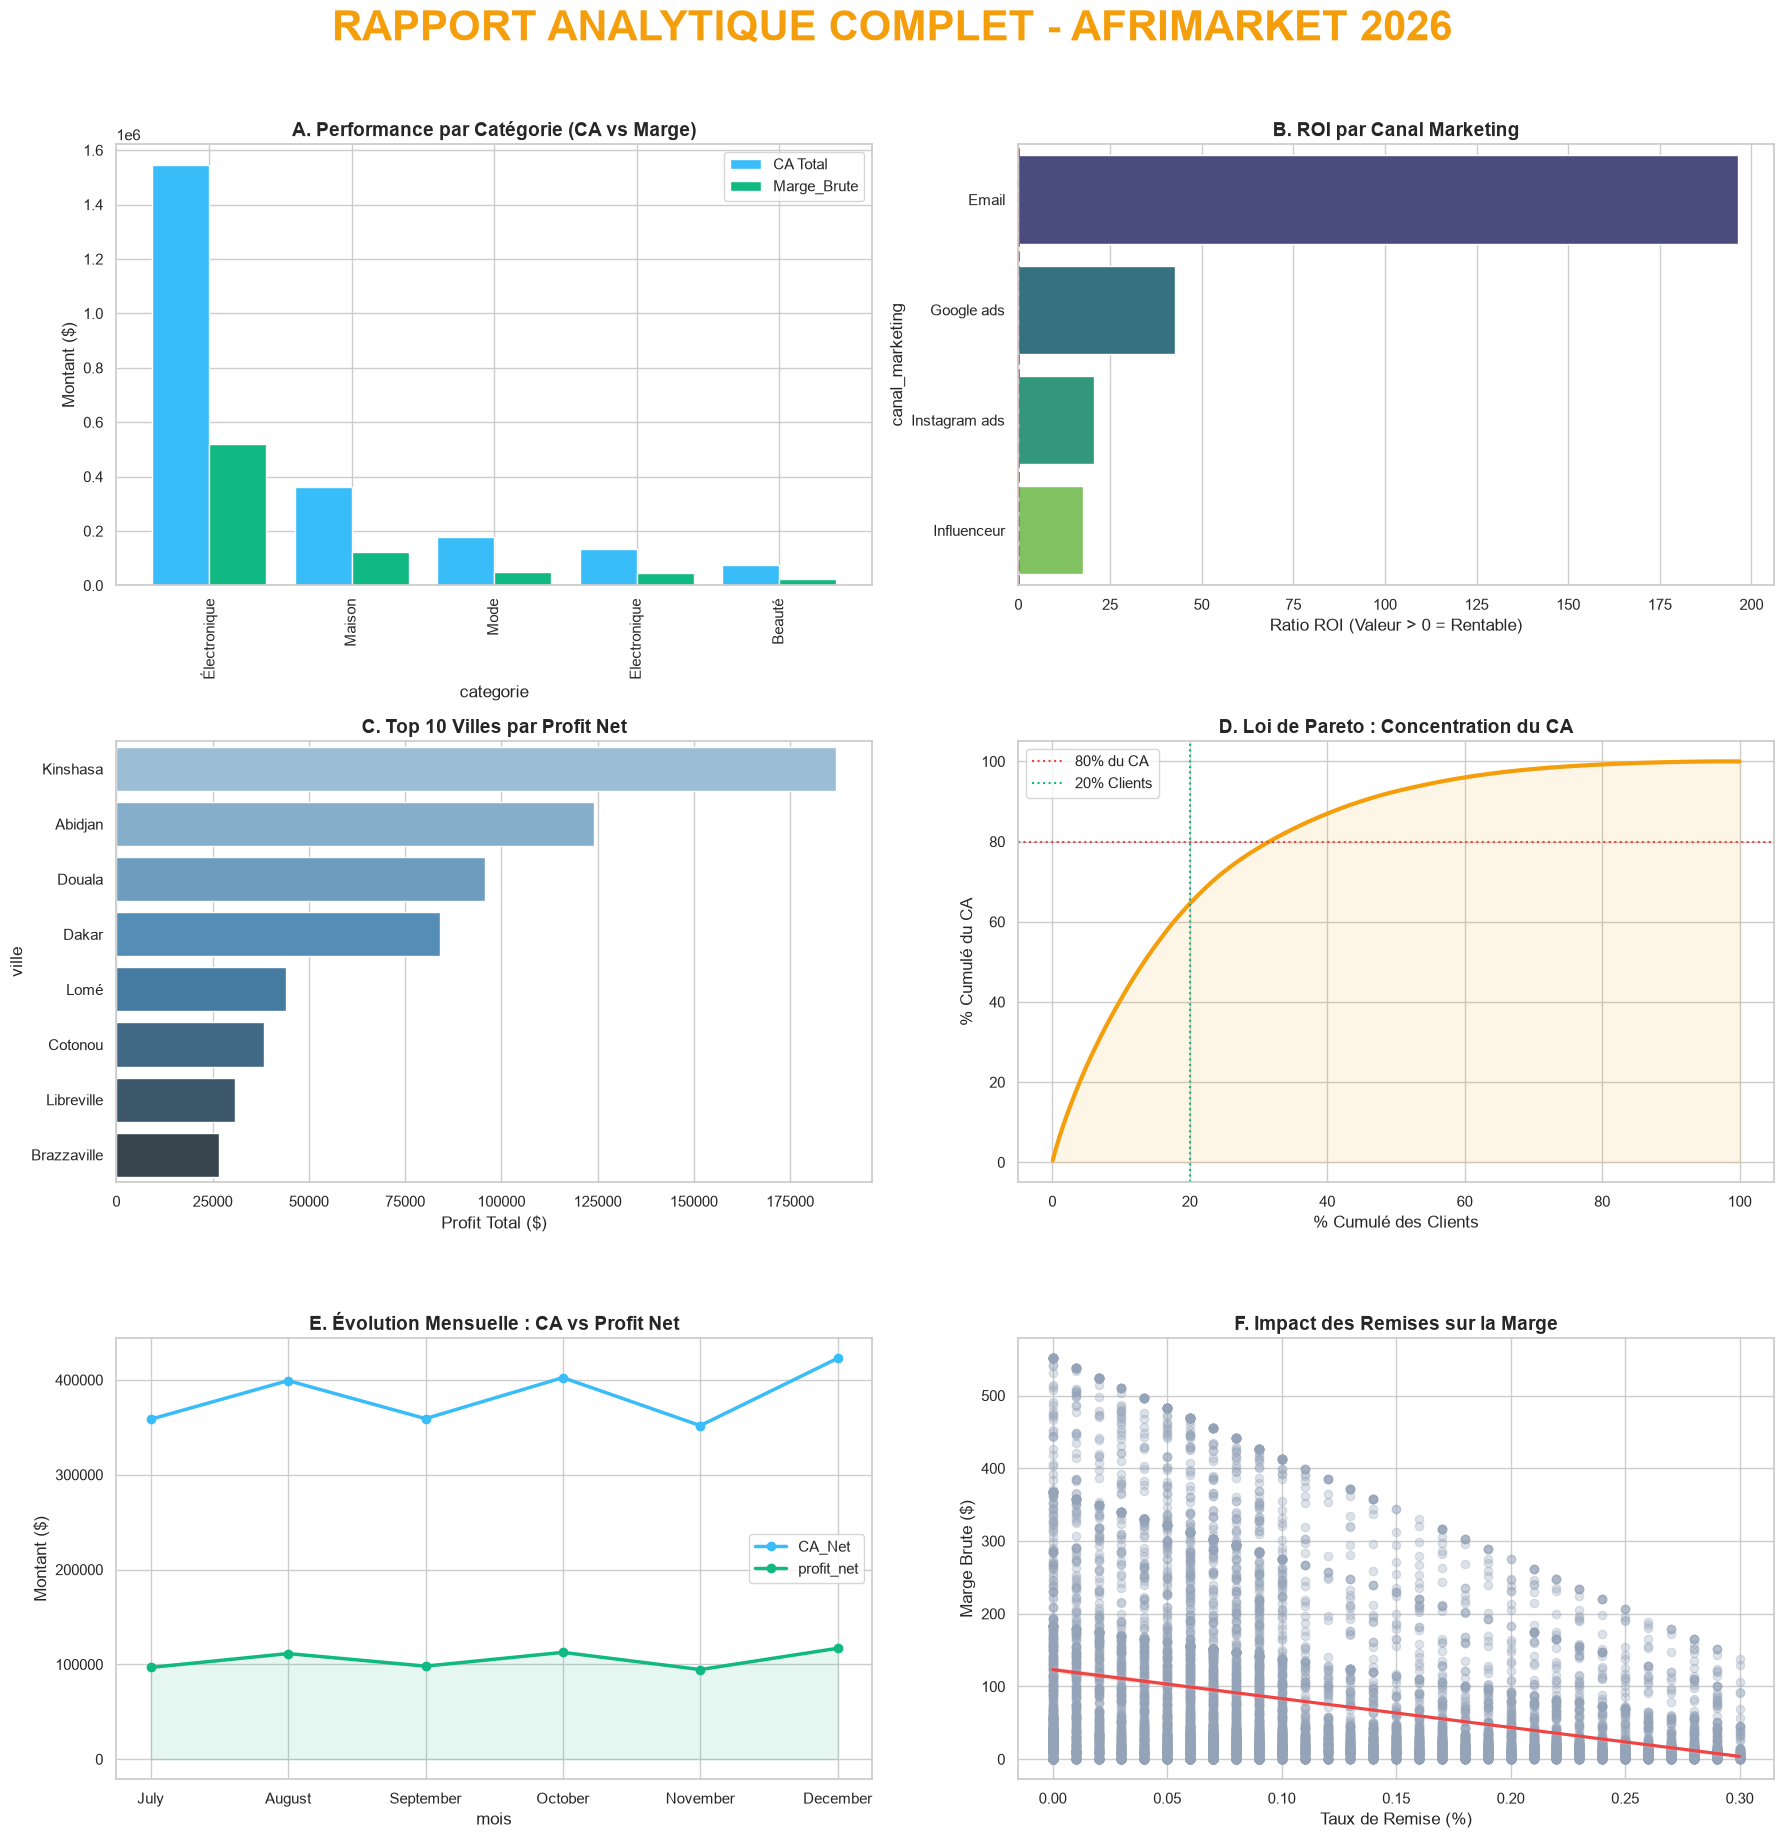

In [39]:
# 1. Configuration globale du style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 2, figsize=(18, 18))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# --- A. TOP 5 CATÉGORIES (CA vs MARGE) ---
cat_data = df.groupby('categorie')[['CA_Net', 'Marge_Brute']].sum().sort_values('CA_Net', ascending=False).head(5)
cat_data.plot(kind='bar', ax=axes[0,0], color=['#38bdf8', '#10b981'], width=0.8)
axes[0,0].set_title('A. Performance par Catégorie (CA vs Marge)', fontsize=14, fontweight='bold')
axes[0,0].set_ylabel('Montant ($)')
axes[0,0].legend(['CA Total', 'Marge_Brute'])

# --- B. RENTABILITÉ MARKETING (ROI par Canal) ---
sns.barplot(data=mkt_perf.sort_values('ROI', ascending=False), x='ROI', y='canal_marketing', ax=axes[0,1], palette='viridis')
axes[0,1].axvline(0, color='#ef4444', linestyle='--', linewidth=2)
axes[0,1].set_title('B. ROI par Canal Marketing', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Ratio ROI (Valeur > 0 = Rentable)')

# --- C. DISTRIBUTION GÉOGRAPHIQUE (Profit Net par Ville) ---
ville_profit = df.groupby('ville')['profit_net'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=ville_profit.values, y=ville_profit.index, ax=axes[1,0], palette='Blues_d')
axes[1,0].set_title('C. Top 10 Villes par Profit Net', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Profit Total ($)')

# --- D. ANALYSE DE PARETO (Concentration du CA) ---
axes[1,1].plot(df_pareto['cum_clients_pct'], df_pareto['cum_ca_pct'], color='#f59e0b', linewidth=3)
axes[1,1].axhline(80, color='#ef4444', linestyle=':', label='80% du CA')
axes[1,1].axvline(20, color='#10b981', linestyle=':', label='20% Clients')
axes[1,1].fill_between(df_pareto['cum_clients_pct'], df_pareto['cum_ca_pct'], color='#f59e0b', alpha=0.1)
axes[1,1].set_title('D. Loi de Pareto : Concentration du CA', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('% Cumulé des Clients')
axes[1,1].set_ylabel('% Cumulé du CA')
axes[1,1].legend()

# --- E. ÉVOLUTION MENSUELLE (CA vs PROFIT NET) ---
evolution_data = df.groupby('mois')[['CA_Net', 'profit_net']].sum().reindex(ordre_mois)
evolution_data.plot(kind='line', marker='o', linewidth=2.5, ax=axes[2,0], color=['#38bdf8', '#10b981'])
axes[2,0].fill_between(evolution_data.index, evolution_data['profit_net'], color='#10b981', alpha=0.1)
axes[2,0].set_title('E. Évolution Mensuelle : CA vs Profit Net', fontsize=14, fontweight='bold')
axes[2,0].set_ylabel('Montant ($)')

# --- F. IMPACT DES REMISES SUR LA MARGE ---
sns.regplot(data=df, x='remise', y='Marge_Brute', 
            scatter_kws={'alpha':0.3, 'color':'#94a3b8'}, line_kws={'color':'#ef4444'}, ax=axes[2,1])
axes[2,1].set_title('F. Impact des Remises sur la Marge', fontsize=14, fontweight='bold')
axes[2,1].set_xlabel('Taux de Remise (%)')
axes[2,1].set_ylabel('Marge Brute ($)')

# Titre général et ajustement
plt.suptitle('RAPPORT ANALYTIQUE COMPLET - AFRIMARKET 2026', fontsize=30, fontweight='bold', color='#f59e0b', y=1.02)
plt.tight_layout()
plt.show()

In [43]:
import unicodedata
from io import BytesIO
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from pptx import Presentation
from pptx.util import Inches, Pt
from pptx.dml.color import RGBColor
from pptx.enum.text import PP_ALIGN, MSO_ANCHOR
from pptx.enum.shapes import MSO_SHAPE
 
# ------------------------------------------------------------------
# 0. Palette et constantes (À DÉFINIR AVANT TOUTE UTILISATION)
# ------------------------------------------------------------------
NAVY = RGBColor(0x0D, 0x1B, 0x3E)
BLUE = RGBColor(0x1F, 0x5F, 0xAA)
TEAL = RGBColor(0x0E, 0x9F, 0x9A)
GOLD = RGBColor(0xD4, 0xA1, 0x2A)
MID = RGBColor(0x5B, 0x67, 0x7A)
LIGHT = RGBColor(0xEE, 0xF2, 0xF7)
WHITE = RGBColor(0xFF, 0xFF, 0xFF)
 
POLICE = "Aptos"  # remplacer par "Calibri" si Aptos n'est pas installée
ORDRE_MOIS_DEFAUT = ["July", "August", "September", "October", "November", "December"]
 
 
def hex_color(color):
    """RGBColor (ou tuple RGB) -> '#rrggbb' pour matplotlib."""
    return "#{:02x}{:02x}{:02x}".format(*[int(v) for v in color])
 
 
NAVY_HEX = hex_color(NAVY)
BLUE_HEX = hex_color(BLUE)
TEAL_HEX = hex_color(TEAL)
GOLD_HEX = hex_color(GOLD)
MID_HEX = hex_color(MID)
LIGHT_HEX = hex_color(LIGHT)
WHITE_HEX = hex_color(WHITE)
 
# ------------------------------------------------------------------
# 1. Préparation des données
# ------------------------------------------------------------------
if "d" in globals() and isinstance(d, pd.DataFrame) and "_categorie" in d.columns:
    source = d.copy()
elif "df" in globals() and isinstance(df, pd.DataFrame):
    source = df.copy()
else:
    raise NameError("Aucun DataFrame trouvé : définis `df` (ou `d`) avant d'exécuter ce bloc.")
 
colonnes_requises = ["CA_Net", "id_client", "id_commande", "statut_commande", "ville"]
manquantes = [c for c in colonnes_requises if c not in source.columns]
if manquantes:
    raise KeyError(f"Colonnes manquantes dans le DataFrame : {manquantes}")
 
 
def normaliser_texte(value):
    texte = str(value).strip().casefold()
    return "".join(
        c for c in unicodedata.normalize("NFKD", texte) if not unicodedata.combining(c)
    )
 
 
# Catégorie
if "_categorie" in source.columns:
    source["_categorie_rapport"] = source["_categorie"].fillna("Non renseignée")
elif "categorie" in source.columns:
    source["_categorie_rapport"] = source["categorie"].map(
        lambda v: {
            "electronique": "Électronique",
            "beaute": "Beauté",
            "maison": "Maison",
            "mode": "Mode",
        }.get(normaliser_texte(v), str(v).strip().capitalize())
    )
else:
    source["_categorie_rapport"] = "Non renseignée"
 
# Profit et indicateur de retour
if "profit_net" not in source.columns:
    source["profit_net"] = (
        source["CA_Net"] - source["cout_marketing"] - source["cout_livraison"]
    )
 
if "indicateur_retour" not in source.columns:
    source["indicateur_retour"] = source["statut_commande"].map(
        lambda v: int(normaliser_texte(v) in {"annulee", "retournee"})
    )
 
# Indicateurs globaux
ca_total = source["CA_Net"].sum()
profit_total = source["profit_net"].sum()
marge_pct = 100 * profit_total / ca_total if ca_total else 0
nb_clients = source["id_client"].nunique()
nb_commandes = source["id_commande"].nunique()
panier_moyen_rapport = (
    source.groupby("id_commande")["CA_Net"].sum().mean() if nb_commandes else 0
)
pct_clients_recurrents = (
    100 * (source.groupby("id_client")["id_commande"].nunique() > 1).mean()
    if nb_clients else 0
)
 
statuts = source["statut_commande"].map(normaliser_texte)
taux_annulation_rapport = 100 * statuts.eq("annulee").mean()
taux_retour_rapport = 100 * statuts.eq("retournee").mean()
 
col_qte = next((c for c in ("quantite", "quantité", "qty") if c in source.columns), None)
nb_qte_nulles = int((source[col_qte] == 0).sum()) if col_qte else 0
 
# Catégories
cat_rapport = (
    source.groupby("_categorie_rapport", as_index=False)
    .agg(CA=("CA_Net", "sum"), Profit=("profit_net", "sum"),
         Taux_incident=("indicateur_retour", "mean"))
    .sort_values("CA", ascending=False)
)
cat_rapport["Taux_incident"] *= 100
 
# Villes
ville_rapport = (
    source.groupby("ville", as_index=False)
    .agg(CA=("CA_Net", "sum"), Profit=("profit_net", "sum"),
         Taux_incident=("indicateur_retour", "mean"))
    .sort_values("CA", ascending=False)
)
ville_rapport["Taux_incident"] *= 100
 
# Mois
if "mois" in source.columns:
    ordre = list(globals().get("ordre_mois", ORDRE_MOIS_DEFAUT))
    mois_brut = source.groupby("mois").agg(CA=("CA_Net", "sum"), Profit=("profit_net", "sum"))
    presents = [m for m in ordre if m in mois_brut.index]
    mois_rapport = mois_brut.loc[presents] if presents else mois_brut.sort_index()
elif "date_commande" in source.columns:
    source["_date_rapport"] = pd.to_datetime(source["date_commande"], errors="coerce")
    mois_rapport = (
        source.dropna(subset=["_date_rapport"])
        .groupby(source["_date_rapport"].dt.to_period("M"))
        .agg(CA=("CA_Net", "sum"), Profit=("profit_net", "sum"))
    )
    mois_rapport.index = mois_rapport.index.astype(str)
else:
    mois_rapport = pd.DataFrame({"CA": [ca_total], "Profit": [profit_total]}, index=["Total"])
 
mois_rapport.index = mois_rapport.index.astype(str)
periode_txt = (
    f"{mois_rapport.index[0]} à {mois_rapport.index[-1]}"
    if len(mois_rapport) > 1 else str(mois_rapport.index[0])
)
 
# Marketing
marketing_rapport = None
if {"canal_marketing", "cout_marketing"}.issubset(source.columns):
    marketing_rapport = source.groupby("canal_marketing").agg(
        CA=("CA_Net", "sum"),
        Cout=("cout_marketing", "sum"),
        Clients=("id_client", "nunique"),
    )
    marketing_rapport["ROI formule"] = (
        (marketing_rapport["CA"] - marketing_rapport["Cout"])
        / marketing_rapport["Cout"].replace(0, np.nan)
    )
    marketing_rapport = marketing_rapport.sort_values("CA", ascending=False)
 
# Pareto clients
pareto_rapport = (
    source.groupby("id_client")["CA_Net"].sum()
    .sort_values(ascending=False)
    .reset_index()
)
pareto_rapport["% clients cumulés"] = 100 * (pareto_rapport.index + 1) / len(pareto_rapport)
pareto_rapport["% CA cumulé"] = (
    100 * pareto_rapport["CA_Net"].cumsum() / pareto_rapport["CA_Net"].sum()
)
part_clients_80_rapport = (
    pareto_rapport.loc[pareto_rapport["% CA cumulé"] >= 80, "% clients cumulés"].min()
    if not pareto_rapport.empty else 0
)
 
# ------------------------------------------------------------------
# 2. Fonctions de mise en page
# ------------------------------------------------------------------
prs_final = Presentation()
prs_final.slide_width = Inches(13.333)
prs_final.slide_height = Inches(7.5)
 
 
def fmt_usd(valeur):
    return f"{valeur:,.0f} $".replace(",", " ")
 
 
def fmt_int(valeur):
    return f"{valeur:,}".replace(",", " ")
 
 
def ajouter_texte(slide, texte, x, y, largeur, hauteur, taille=16,
                  couleur=NAVY, gras=False, alignement=PP_ALIGN.LEFT, espace_apres=0):
    zone = slide.shapes.add_textbox(Inches(x), Inches(y), Inches(largeur), Inches(hauteur))
    tf = zone.text_frame
    tf.word_wrap = True
    tf.margin_left = Inches(0.08)
    tf.margin_right = Inches(0.08)
    tf.margin_top = Inches(0.04)
    tf.margin_bottom = Inches(0.03)
 
    # Un paragraphe par ligne : les "\n" sont ainsi correctement rendus
    for i, ligne in enumerate(str(texte).split("\n")):
        p = tf.paragraphs[0] if i == 0 else tf.add_paragraph()
        p.alignment = alignement
        if espace_apres:
            p.space_after = Pt(espace_apres)
        run = p.add_run()
        run.text = ligne
        run.font.name = POLICE
        run.font.size = Pt(taille)
        run.font.bold = gras
        run.font.color.rgb = couleur
    return zone
 
 
def ajouter_fond(slide, couleur=WHITE):
    fond = slide.background.fill
    fond.solid()
    fond.fore_color.rgb = couleur
 
 
def nouvelle_slide(titre, sous_titre=None):
    slide = prs_final.slides.add_slide(prs_final.slide_layouts[6])
    ajouter_fond(slide)
    ajouter_texte(slide, titre, 0.65, 0.35, 12.0, 0.55, 25, NAVY, True)
    if sous_titre:
        ajouter_texte(slide, sous_titre, 0.68, 0.92, 12.0, 0.35, 10, MID)
    bande = slide.shapes.add_shape(
        MSO_SHAPE.RECTANGLE, Inches(0.68), Inches(1.32), Inches(1.05), Inches(0.055)
    )
    bande.fill.solid()
    bande.fill.fore_color.rgb = TEAL
    bande.line.fill.background()
    ajouter_texte(slide, "AFRIMARKET  |  RAPPORT D’ANALYSE", 0.68, 7.12, 8.5, 0.2, 8, MID)
    ajouter_texte(slide, f"{len(prs_final.slides):02d}", 12.15, 7.08, 0.45, 0.25, 9, MID,
                  alignement=PP_ALIGN.RIGHT)
    return slide
 
 
def ajouter_carte(slide, x, y, largeur, hauteur, titre, valeur, detail=""):
    forme = slide.shapes.add_shape(
        MSO_SHAPE.ROUNDED_RECTANGLE, Inches(x), Inches(y), Inches(largeur), Inches(hauteur)
    )
    forme.fill.solid()
    forme.fill.fore_color.rgb = LIGHT
    forme.line.color.rgb = LIGHT
    ajouter_texte(slide, titre.upper(), x + 0.18, y + 0.15, largeur - 0.36, 0.25, 9, MID, True)
    if valeur:
        ajouter_texte(slide, valeur, x + 0.18, y + 0.48, largeur - 0.36, 0.48, 22, BLUE, True)
    if detail:
        dy = 1.02 if valeur else 0.5
        ajouter_texte(slide, detail, x + 0.18, y + dy, largeur - 0.36, hauteur - dy - 0.06, 10, MID)
 
 
def ajouter_graphique(slide, figure, x, y, largeur, hauteur):
    """Insère la figure en conservant ses proportions, centrée dans la zone donnée."""
    buf = BytesIO()
    figure.savefig(buf, format="png", dpi=180, bbox_inches="tight", facecolor="white")
    plt.close(figure)
    buf.seek(0)
    with Image.open(buf) as im:
        w_px, h_px = im.size
    ratio = w_px / h_px
    w, h = largeur, largeur / ratio
    if h > hauteur:
        h, w = hauteur, hauteur * ratio
    buf.seek(0)
    slide.shapes.add_picture(
        buf, Inches(x + (largeur - w) / 2), Inches(y + (hauteur - h) / 2),
        width=Inches(w), height=Inches(h),
    )
 
 
def ajouter_liste(slide, lignes, x, y, largeur, hauteur, taille=14):
    texte = "\n".join(f"•  {ligne}" for ligne in lignes)
    ajouter_texte(slide, texte, x, y, largeur, hauteur, taille, NAVY, espace_apres=4)
 
 
def ajouter_tableau(slide, entetes, lignes, x, y, largeur, hauteur, largeurs=None, taille=10):
    tableau = slide.shapes.add_table(
        len(lignes) + 1, len(entetes), Inches(x), Inches(y), Inches(largeur), Inches(hauteur)
    ).table
 
    if largeurs:
        for index, proportion in enumerate(largeurs):
            tableau.columns[index].width = Inches(largeur * proportion)
 
    for r, ligne in enumerate([entetes] + lignes):
        for c, valeur in enumerate(ligne):
            cellule = tableau.cell(r, c)
            cellule.text = str(valeur)
            cellule.margin_left = Inches(0.07)
            cellule.margin_right = Inches(0.05)
            cellule.margin_top = Inches(0.04)
            cellule.margin_bottom = Inches(0.03)
            cellule.vertical_anchor = MSO_ANCHOR.MIDDLE
            cellule.fill.solid()
            cellule.fill.fore_color.rgb = NAVY if r == 0 else (LIGHT if r % 2 else WHITE)
            for paragraphe in cellule.text_frame.paragraphs:
                for run in paragraphe.runs:
                    run.font.name = POLICE
                    run.font.size = Pt(taille)
                    run.font.bold = (r == 0)
                    run.font.color.rgb = WHITE if r == 0 else NAVY
 
 
def style_axes(ax, grille="y"):
    ax.grid(axis=grille, alpha=0.2)
    ax.spines[["top", "right"]].set_visible(False)
 
 
# ------------------------------------------------------------------
# 3. Couverture
# ------------------------------------------------------------------
slide = prs_final.slides.add_slide(prs_final.slide_layouts[6])
ajouter_fond(slide, NAVY)
accent = slide.shapes.add_shape(MSO_SHAPE.RECTANGLE, Inches(0), Inches(0), Inches(0.22), Inches(7.5))
accent.fill.solid()
accent.fill.fore_color.rgb = TEAL
accent.line.fill.background()
 
ajouter_texte(slide, "AFRIMARKET", 0.9, 1.15, 8.5, 0.55, 20, TEAL, True)
ajouter_texte(slide, "Rapport d’analyse\ndes performances", 0.9, 2.0, 10.8, 1.6, 34, WHITE, True)
ajouter_texte(slide, "Ventes • rentabilité • clients • marketing • qualité des données",
              0.95, 4.0, 10.5, 0.5, 16, LIGHT)
ajouter_texte(
    slide,
    f"{fmt_int(len(source))} lignes analysées  |  {fmt_int(nb_clients)} clients  |  "
    f"CA net : {fmt_usd(ca_total)}",
    0.95, 5.0, 11.2, 0.5, 14, WHITE,
)
ajouter_texte(slide, "Synthèse décisionnelle et recommandations", 0.95, 6.35, 10, 0.35, 11, LIGHT)
 
# ------------------------------------------------------------------
# 4. Synthèse exécutive
# ------------------------------------------------------------------
slide = nouvelle_slide("Synthèse exécutive", "Les principaux indicateurs et enseignements de la période étudiée")
ajouter_carte(slide, 0.7, 1.65, 2.85, 1.55, "Chiffre d’affaires net", fmt_usd(ca_total))
ajouter_carte(slide, 3.75, 1.65, 2.85, 1.55, "Profit net estimé", fmt_usd(profit_total))
ajouter_carte(slide, 6.8, 1.65, 2.85, 1.55, "Marge estimée", f"{marge_pct:.1f} %")
ajouter_carte(slide, 9.85, 1.65, 2.8, 1.55, "Clients récurrents", f"{pct_clients_recurrents:.1f} %")
 
cat_top = cat_rapport.iloc[0]["_categorie_rapport"] if not cat_rapport.empty else "—"
ville_top = ville_rapport.iloc[0]["ville"] if not ville_rapport.empty else "—"
mois_top = mois_rapport["CA"].idxmax() if not mois_rapport.empty else "—"
 
ajouter_texte(slide, "À retenir", 0.8, 3.65, 3, 0.35, 18, NAVY, True)
ajouter_liste(slide, [
    f"{cat_top} est la première catégorie en chiffre d’affaires.",
    f"{ville_top} est la ville la plus contributrice au chiffre d’affaires.",
    f"{mois_top} est le mois le plus performant de la période observée.",
    f"Le panier moyen par commande est de {panier_moyen_rapport:,.2f} $.".replace(",", " "),
    "Les décisions d’investissement doivent tenir compte des limites méthodologiques.",
], 0.85, 4.1, 11.6, 2.5, 14)
 
# ------------------------------------------------------------------
# 5. Périmètre et qualité des données
# ------------------------------------------------------------------
slide = nouvelle_slide("Périmètre et qualité des données",
                       "Les résultats sont descriptifs et dépendent des règles de calcul appliquées")
ajouter_carte(slide, 0.8, 1.65, 3.6, 1.45, "Lignes analysées", fmt_int(len(source)))
ajouter_carte(slide, 4.85, 1.65, 3.6, 1.45, "Commandes distinctes", fmt_int(nb_commandes))
ajouter_carte(slide, 8.9, 1.65, 3.6, 1.45, "Clients distincts", fmt_int(nb_clients))
ajouter_texte(slide, "Points de vigilance à valider", 0.85, 3.55, 6, 0.4, 18, NAVY, True)
 
vigilance = [
    "Le profit est estimé avec une hypothèse de coût des marchandises à 60 % du prix.",
    "Le CA doit être rapproché des statuts : les annulations et retours ne sont pas automatiquement exclus.",
]
if nb_qte_nulles > 0:
    vigilance.append(
        f"{fmt_int(nb_qte_nulles)} lignes à quantité nulle ont été observées ; leur signification métier doit être confirmée."
    )
vigilance += [
    "Le taux d’incident combine retours et annulations lorsqu’il est calculé avec l’indicateur agrégé.",
    "Les taux présentés sur les lignes ne sont pas nécessairement des taux par commande.",
]
ajouter_liste(slide, vigilance, 0.9, 4.0, 11.6, 2.8, 13)
 
# ------------------------------------------------------------------
# 6. Performance globale
# ------------------------------------------------------------------
slide = nouvelle_slide("Performance globale", "Chiffre d’affaires et profit estimé sur la période disponible")
fig, ax = plt.subplots(figsize=(9.5, 4.1))
x_pos = np.arange(len(mois_rapport))
ax.bar(x_pos - 0.18, mois_rapport["CA"] / 1000, width=0.36, color=BLUE_HEX, label="CA net")
ax.bar(x_pos + 0.18, mois_rapport["Profit"] / 1000, width=0.36, color=TEAL_HEX, label="Profit estimé")
ax.set_xticks(x_pos)
ax.set_xticklabels(mois_rapport.index, rotation=25, ha="right")
ax.set_ylabel("Milliers de dollars")
ax.set_title("CA net et profit estimé par mois", loc="left", fontweight="bold")
style_axes(ax, "y")
ax.legend(frameon=False)
ajouter_graphique(slide, fig, 0.7, 1.65, 8.1, 4.75)
 
meilleur_mois = mois_rapport["CA"].idxmax() if not mois_rapport.empty else "—"
plus_faible_mois = mois_rapport["CA"].idxmin() if not mois_rapport.empty else "—"
ajouter_texte(slide, "Lecture", 9.2, 1.85, 3, 0.35, 17, NAVY, True)
ajouter_liste(slide, [
    f"Meilleur mois : {meilleur_mois}.",
    f"Mois le plus faible : {plus_faible_mois}.",
    "La période disponible ne permet pas de conclure à une tendance annuelle.",
    f"Annulations observées : {taux_annulation_rapport:.2f} % des lignes.",
    f"Retours observés : {taux_retour_rapport:.2f} % des lignes.",
], 9.2, 2.3, 3.3, 3.8, 12)
 
# ------------------------------------------------------------------
# 7. Analyse par catégorie
# ------------------------------------------------------------------
slide = nouvelle_slide("Analyse par catégorie",
                       "Concentration du chiffre d’affaires et contribution au profit estimé")
fig, ax = plt.subplots(figsize=(7.0, 4.2))
cat_plot = cat_rapport.sort_values("CA")
ax.barh(cat_plot["_categorie_rapport"], cat_plot["CA"] / 1000, color=BLUE_HEX)
ax.set_xlabel("CA net (milliers de dollars)")
ax.set_title("Chiffre d’affaires net par catégorie", loc="left", fontweight="bold")
style_axes(ax, "x")
ajouter_graphique(slide, fig, 0.65, 1.7, 6.2, 4.7)
 
cat_rows = [
    [l["_categorie_rapport"], fmt_usd(l["CA"]), fmt_usd(l["Profit"]), f'{l["Taux_incident"]:.1f} %']
    for _, l in cat_rapport.iterrows()
]
ajouter_tableau(slide, ["Catégorie", "CA net", "Profit estimé", "Incidents"],
                cat_rows, 7.0, 1.9, 5.6, 3.8, [0.32, 0.24, 0.26, 0.18], 9)
part_top_cat = 100 * cat_rapport.iloc[0]["CA"] / ca_total if ca_total else 0
ajouter_texte(
    slide,
    f"{cat_top} représente {part_top_cat:.1f} % du CA. Examiner ses retours par produit avant d’accélérer davantage l’offre.",
    7.05, 5.95, 5.4, 0.75, 12, NAVY, True,
)
 
# ------------------------------------------------------------------
# 8. Analyse géographique
# ------------------------------------------------------------------
slide = nouvelle_slide("Analyse géographique",
                       "Contribution des villes au chiffre d’affaires et au profit estimé")
fig, ax = plt.subplots(figsize=(7.0, 4.2))
ville_plot = ville_rapport.sort_values("CA")
ax.barh(ville_plot["ville"], ville_plot["CA"] / 1000, color=TEAL_HEX)
ax.set_xlabel("CA net (milliers de dollars)")
ax.set_title("Chiffre d’affaires net par ville", loc="left", fontweight="bold")
style_axes(ax, "x")
ajouter_graphique(slide, fig, 0.65, 1.7, 6.2, 4.7)
 
ville_rows = [
    [l["ville"], fmt_usd(l["CA"]), fmt_usd(l["Profit"]), f'{l["Taux_incident"]:.1f} %']
    for _, l in ville_rapport.head(6).iterrows()
]
ajouter_tableau(slide, ["Ville", "CA net", "Profit estimé", "Incidents"],
                ville_rows, 7.0, 1.9, 5.6, 3.8, [0.24, 0.27, 0.29, 0.20], 9)
ville_risque = ville_rapport.sort_values("Taux_incident", ascending=False).iloc[0]["ville"]
ajouter_texte(
    slide,
    f"Priorité opérationnelle : investiguer les retours et annulations à {ville_risque}, puis comparer les motifs par produit et canal.",
    7.05, 5.95, 5.4, 0.75, 12, NAVY, True,
)
 
# ------------------------------------------------------------------
# 9. Évolution mensuelle
# ------------------------------------------------------------------
slide = nouvelle_slide("Évolution mensuelle",
                       "Suivre les variations de revenus sans les confondre avec une croissance annuelle")
fig, ax = plt.subplots(figsize=(10, 4.6))
ax.plot(mois_rapport.index, mois_rapport["CA"] / 1000, marker="o",
        linewidth=2.5, color=BLUE_HEX, label="CA net")
ax.plot(mois_rapport.index, mois_rapport["Profit"] / 1000, marker="o",
        linewidth=2.5, color=TEAL_HEX, label="Profit estimé")
ax.set_ylabel("Milliers de dollars")
style_axes(ax, "both")
ax.legend(frameon=False)
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
ajouter_graphique(slide, fig, 0.8, 1.7, 11.7, 4.8)
ajouter_texte(
    slide,
    f"À interpréter comme une comparaison des mois observés ({periode_txt}), et non comme une tendance annuelle.",
    0.9, 6.55, 11.5, 0.35, 11, MID,
)
 
# ------------------------------------------------------------------
# 10. Analyse marketing
# ------------------------------------------------------------------
slide = nouvelle_slide("Performance marketing",
                       "Le ROI présenté est un indicateur simplifié, pas une rentabilité nette complète")
if marketing_rapport is not None and not marketing_rapport.empty:
    fig, ax = plt.subplots(figsize=(7.0, 4.2))
    mkt_plot = marketing_rapport.dropna(subset=["ROI formule"]).sort_values("ROI formule")
    ax.barh(mkt_plot.index.astype(str), mkt_plot["ROI formule"], color=GOLD_HEX)
    ax.axvline(0, color=NAVY_HEX, linewidth=1)
    ax.set_xlabel("(CA − coût marketing) / coût marketing")
    ax.set_title("ROI simplifié par canal", loc="left", fontweight="bold")
    style_axes(ax, "x")
    ajouter_graphique(slide, fig, 0.65, 1.75, 6.3, 4.3)
 
    mkt_rows = [
        [canal, fmt_usd(l["CA"]), fmt_usd(l["Cout"]),
         f'{l["ROI formule"]:.1f}' if pd.notna(l["ROI formule"]) else "—"]
        for canal, l in marketing_rapport.iterrows()
    ]
    ajouter_tableau(slide, ["Canal", "CA attribué", "Coût", "ROI*"],
                    mkt_rows, 7.1, 1.95, 5.45, 3.4, [0.30, 0.27, 0.25, 0.18], 9)
 
    roi_valide = marketing_rapport["ROI formule"].dropna()
    canal_roi = roi_valide.idxmax() if not roi_valide.empty else "—"
    canal_ca = marketing_rapport["CA"].idxmax()
    ajouter_liste(slide, [
        f"{canal_roi} présente le ROI simplifié le plus élevé.",
        f"{canal_ca} génère le CA attribué le plus important.",
        "Le calcul ne déduit ni le coût des marchandises ni les autres coûts.",
        "Définir une règle d’attribution avant de comparer les canaux.",
    ], 0.85, 6.1, 11.8, 0.9, 10)
else:
    ajouter_texte(slide, "Les colonnes marketing (canal_marketing, cout_marketing) sont absentes du jeu de données.",
                  0.85, 2.0, 11.5, 0.6, 14, MID)
 
# ------------------------------------------------------------------
# 11. Clients et concentration du chiffre d'affaires
# ------------------------------------------------------------------
slide = nouvelle_slide("Clients et concentration du CA",
                       "Fidélité mesurée par le nombre de commandes distinctes par client")
fig, ax = plt.subplots(figsize=(7.2, 4.3))
ax.plot(pareto_rapport["% clients cumulés"], pareto_rapport["% CA cumulé"],
        color=BLUE_HEX, linewidth=2.5)
ax.axhline(80, color=GOLD_HEX, linestyle="--", label="80 % du CA")
if pd.notna(part_clients_80_rapport):
    ax.axvline(part_clients_80_rapport, color=TEAL_HEX, linestyle=":", label="Seuil observé")
ax.set_xlabel("% cumulé des clients classés par CA")
ax.set_ylabel("% cumulé du CA")
ax.set_title("Courbe de concentration (Pareto)", loc="left", fontweight="bold")
style_axes(ax, "both")
ax.legend(frameon=False)
ajouter_graphique(slide, fig, 0.65, 1.75, 7.1, 4.65)
 
ajouter_carte(slide, 8.2, 1.95, 4.0, 1.55, "Clients récurrents", f"{pct_clients_recurrents:.1f} %",
              "Clients avec plus d’une commande distincte")
ajouter_carte(slide, 8.2, 3.85, 4.0, 1.55, "Clients pour atteindre 80 % du CA",
              f"{part_clients_80_rapport:.1f} %", "Part cumulée de la clientèle, selon le Pareto")
ajouter_texte(
    slide,
    "Piste d’action : fidéliser les meilleurs clients tout en développant l’activité des segments moins contributeurs.",
    8.25, 5.75, 3.9, 0.9, 11, NAVY, True,
)
 
# ------------------------------------------------------------------
# 12. Recommandations prioritaires
# ------------------------------------------------------------------
slide = nouvelle_slide("Recommandations prioritaires",
                       "Actions proposées pour fiabiliser les décisions et améliorer le pilotage")
recommandations_finales = [
    ("01", "Fiabiliser le CA", "Valider les quantités nulles et définir le traitement des annulations et retours."),
    ("02", "Harmoniser les catégories", "Normaliser les libellés avant chaque agrégation, tableau ou visualisation."),
    ("03", "Réduire les retours", "Analyser les motifs par produit, ville, canal et statut de commande."),
    ("04", "Mesurer la rentabilité réelle", "Intégrer les coûts complets et documenter la méthode d’attribution marketing."),
    ("05", "Développer la fidélité", "Suivre les cohortes, la fréquence d’achat et la contribution client."),
    ("06", "Piloter dans le temps", "Mettre à jour mensuellement des indicateurs cohérents et comparables."),
]
for index, (numero, titre, detail) in enumerate(recommandations_finales):
    col, row = index % 2, index // 2
    ajouter_carte(slide, 0.85 + col * 6.15, 1.7 + row * 1.55, 5.65, 1.25,
                  f"{numero} · {titre}", "", detail)
 
# ------------------------------------------------------------------
# 13. Définitions et limites
# ------------------------------------------------------------------
slide = nouvelle_slide("Annexe — définitions et limites", "Interprétation des indicateurs présentés dans ce rapport")
ajouter_liste(slide, [
    "CA net : prix unitaire × quantité × (1 − remise), selon les colonnes disponibles.",
    "Profit net estimé : marge calculée avec une hypothèse de coût des marchandises, moins marketing et livraison.",
    "Panier moyen : moyenne du CA net regroupé par identifiant de commande.",
    "Clients récurrents : clients ayant passé plus d’une commande distincte.",
    "ROI simplifié : (CA attribué − coût marketing) / coût marketing ; il ne s’agit pas d’un ROI net complet.",
    "Taux d’annulation et taux de retour : proportions calculées sur les lignes du dataset.",
    "Les résultats sont descriptifs ; ils ne démontrent pas de lien causal entre marketing et ventes.",
], 0.9, 1.75, 11.6, 4.5, 14)
ajouter_texte(
    slide,
    "Avant diffusion externe : valider les règles de calcul avec les équipes Finance, Opérations et Marketing.",
    0.9, 6.35, 11.4, 0.45, 12, TEAL, True,
)
 
# ------------------------------------------------------------------
# 14. Sauvegarde
# ------------------------------------------------------------------
fichier_rapport_final = "rapport_analyse_afrimarket_final.pptx"
prs_final.save(fichier_rapport_final)
 
print(f"Rapport PowerPoint créé : {fichier_rapport_final}")
print(f"{len(prs_final.slides)} diapositives générées.")
 


Rapport PowerPoint créé : rapport_analyse_afrimarket_final.pptx
11 diapositives générées.
